In [1]:
# import sys
# sys.path.insert(0, "/srv/user/azhar.akhmetova/corrViT/analysis/src")
import os, glob, argparse, json, csv
csv.field_size_limit(50_000_000)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from v1t.utils import utils, tensorboard
tensorboard.set_font()

from pathlib import Path
from typing import Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## responses probe

In [2]:
def parse_fraction(sel_dir: Path) -> float | None:
    """
    sel_dir name is expected to be like 'sel_frac_0.05' or 'sel_frac_1.0'.
    """
    name = sel_dir.name
    if not name.startswith("sel_frac_"):
        return None
    frac_str = name.split("sel_frac_")[1]
    try:
        return float(frac_str)
    except ValueError:
        return None


def best_row_from_csv(csv_path: Path, metric: str) -> dict | None:
    """
    Return the row (as dict) with the smallest final_val_mse in a single metrics.csv.
    If no valid final_val_mse is found, returns None.
    """
    best = None
    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if metric == "final_val_mse":
                val_str = row.get("final_val_mse", "")
                if not val_str:
                    continue
                try:
                    v = float(val_str)
                except ValueError:
                    continue
                if best is None or v < float(best["final_val_mse"]):
                    best = row
            if metric == "final_val_corr":
                val_str = row.get("final_val_corr", "")
                if not val_str:
                    continue
                try:
                    v = float(val_str)
                except ValueError:
                    continue
                if best is None or v > float(best["final_val_corr"]):
                    best = row
    return best


def collect_best_for_fraction(
    sel_dir: Path,
    metric: str = "final_val_mse",
) -> dict | None:
    """
    For a given sel_frac_* directory, scan all metrics.csv files under
    sel_dir / pooling_folder (or sel_dir if pooling_folder is None) and
    pick the row with the best (lowest) value of `metric`.
    """
    frac = parse_fraction(sel_dir)
    if frac is None:
        return None

    # restrict search to chosen pooling folder, e.g. attention_p / max_p / linear_p
    search_root = sel_dir
    if not search_root.is_dir():
        # nothing for this fraction with that pooling
        return None

    best_row = None
    for csv_path in search_root.rglob("metrics.csv"):
        row = best_row_from_csv(csv_path, metric=metric)
        if row is None:
            continue
        if best_row is None or float(row[metric]) < float(best_row[metric]):
            best_row = row

    if best_row is None:
        return None

    # Collect all requested metrics for this fraction
    out = {
        "frac": frac,
        "sweep_id": best_row.get("sweep_id", ""),
        "run_id": best_row.get("run_id", ""),
        "final_val_mse": float(best_row["final_val_mse"]),
        "final_test_mse": float(best_row["final_test_mse"]),
        "final_val_r2avg": float(best_row["final_val_r2avg"]),
        "final_test_r2avg": float(best_row["final_test_r2avg"]),
        # list-valued metrics: keep as raw strings (can parse later if needed)
        "final_val_corr": best_row.get("final_val_corr", ""),
        "final_test_corr": best_row.get("final_test_corr", ""),
    }
    return out


def collect_all_fractions(
    base_dir: Path,
    metric: str = "final_val_mse",
) -> list[dict]:
    """
    base_dir: <output_dir>/analysis/<representation_type>
    Returns a sorted list (by frac) of dicts, one per fraction,
    using metrics from the given pooling_folder inside each sel_frac_*.
    """
    results = []
    for sel_dir in base_dir.glob("sel_frac_*"):
        if not sel_dir.is_dir():
            continue
        best = collect_best_for_fraction(sel_dir, metric=metric)
        if best is not None:
            results.append(best)

    results.sort(key=lambda r: r["frac"])
    return results

def save_summary_csv(results: list[dict], out_path: Path) -> None:
    """
    Save best metrics per fraction into a summary CSV.
    """
    if not results:
        print("No results to save.")
        return

    fieldnames = [
        "frac",
        "sweep_id",
        "run_id",
        "final_val_mse",
        "final_test_mse",
        "final_val_r2avg",
        "final_test_r2avg",
        "final_val_corr",
        "final_test_corr",
    ]

    with out_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)

    print(f"Saved summary to {out_path}")

In [13]:
K = 4
ALPHA = "06"

In [14]:
# linear reg on responses
dataset_name = f"k_{K}_a_{ALPHA}_b1e7_poisson"
lat = "latents_"
base_dir = Path(f"/mnt/lustre-grete/usr/u12008/responses_{lat}probe") / Path(dataset_name)
if not base_dir.exists():
    raise SystemExit(f"Base directory does not exist: {base_dir}")

print(f"Collecting best runs under {base_dir}")
results = collect_all_fractions(base_dir, metric="final_val_corr")
if not results:
    raise SystemExit("No valid metrics.csv files found.")

# Save summary CSV
summary_csv = base_dir / f"best_by_fraction_corr.csv"
save_summary_csv(results, summary_csv)

Saved summary to /mnt/lustre-grete/usr/u12008/responses_latents_probe/k_4_a_06_b1e7_poisson/best_by_fraction_corr.csv


## latent decoding 

In [2]:
def parse_fraction(sel_dir: Path) -> float | None:
    """
    sel_dir name is expected to be like 'sel_frac_0.05' or 'sel_frac_1.0'.
    """
    name = sel_dir.name
    if not name.startswith("sel_frac_"):
        return None
    frac_str = name.split("sel_frac_")[1]
    try:
        return float(frac_str)
    except ValueError:
        return None


def best_row_from_csv(csv_path: Path) -> dict | None:
    """
    Return the row (as dict) with the smallest final_val_mse in a single metrics.csv.
    If no valid final_val_mse is found, returns None.
    """
    best = None
    with csv_path.open("r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            val_str = row.get("final_val_mse", "")
            if not val_str:
                continue
            try:
                v = float(val_str)
            except ValueError:
                continue
            if best is None or v < float(best["final_val_mse"]):
                best = row
    return best


def collect_best_for_fraction(
    sel_dir: Path,
    metric: str = "final_val_mse",
    pooling_folder: str | None = None,
) -> dict | None:
    """
    For a given sel_frac_* directory, scan all metrics.csv files under
    sel_dir / pooling_folder (or sel_dir if pooling_folder is None) and
    pick the row with the best (lowest) value of `metric`.
    """
    frac = parse_fraction(sel_dir)
    if frac is None:
        return None

    # restrict search to chosen pooling folder, e.g. attention_p / max_p / linear_p
    search_root = sel_dir / pooling_folder if pooling_folder is not None else sel_dir
    if not search_root.is_dir():
        # nothing for this fraction with that pooling
        return None

    best_row = None
    for csv_path in search_root.rglob("metrics.csv"):
        row = best_row_from_csv(csv_path)
        if row is None:
            continue
        if best_row is None or float(row[metric]) < float(best_row[metric]):
            best_row = row

    if best_row is None:
        return None

    # Collect all requested metrics for this fraction
    out = {
        "frac": frac,
        "sweep_id": best_row.get("sweep_id", ""),
        "run_id": best_row.get("run_id", ""),
        "final_val_mse": float(best_row["final_val_mse"]),
        "final_test_mse": float(best_row["final_test_mse"]),
        "final_val_r2avg": float(best_row["final_val_r2avg"]),
        "final_test_r2avg": float(best_row["final_test_r2avg"]),
        # list-valued metrics: keep as raw strings (can parse later if needed)
        "final_val_psnr": best_row.get("final_val_psnr", ""),
        "final_test_psnr": best_row.get("final_test_psnr", ""),
        "final_val_r2_each": best_row.get("final_val_r2_each", ""),
        "final_test_r2_each": best_row.get("final_test_r2_each", ""),
    }
    return out


def collect_all_fractions(
    base_dir: Path,
    metric: str = "final_val_mse",
    pooling_folder: str | None = None,
) -> list[dict]:
    """
    base_dir: <output_dir>/analysis/<representation_type>
    Returns a sorted list (by frac) of dicts, one per fraction,
    using metrics from the given pooling_folder inside each sel_frac_*.
    """
    results = []
    for sel_dir in base_dir.glob("sel_frac_*"):
        if not sel_dir.is_dir():
            continue
        best = collect_best_for_fraction(sel_dir, metric=metric, pooling_folder=pooling_folder)
        if best is not None:
            results.append(best)

    results.sort(key=lambda r: r["frac"])
    return results

def save_summary_csv(results: list[dict], out_path: Path) -> None:
    """
    Save best metrics per fraction into a summary CSV.
    """
    if not results:
        print("No results to save.")
        return

    fieldnames = [
        "frac",
        "sweep_id",
        "run_id",
        "final_val_mse",
        "final_test_mse",
        "final_val_r2avg",
        "final_test_r2avg",
        "final_val_psnr",
        "final_test_psnr",
        "final_val_r2_each",
        "final_test_r2_each",
    ]

    with out_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in results:
            writer.writerow(row)

    print(f"Saved summary to {out_path}")

In [45]:
K = 24
ALPHA = "max"
FRAC_INPUT_MODEL = "20"#["00", "001", "02", "03", "05", "10", "20", "50"]
SEED = 1
LR = "004"

In [41]:
out_dir = f"/user/azhar.akhmetova/u12008/neuro-transformer/runs_debug/analysis_bs16/k_{K}/a_{ALPHA}/seed_{SEED}/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"

In [46]:
parser = argparse.ArgumentParser(
    description="Collect best linear-probe metrics per fraction and plot MSE vs fraction."
)
parser.add_argument("--output_dir", type=str, required=True,
    help="Same output_dir used during training.",
)
parser.add_argument("--representation_type", type=str, required=True,
    choices=["initial", "initial_old", "after_sa", "after_core", "queries"],
    help="Representation type: matches training script.",
)
parser.add_argument("--out_prefix", type=str, default="best_by_fraction",
    help="Prefix for summary CSV and plots.",
)
parser.add_argument("--pooling_type", type=str, default=None,
    help="Pooling type subfolder to restrict search to (e.g. attention_p, max_p). If not set, searches all pooling types.",
)

args = parser.parse_args([
    "--output_dir", f"{out_dir}",
    "--representation_type", "initial",
    "--pooling_type", "attention_p",
])

In [43]:
args.representation_type

'initial'

In [47]:
model_name = f"k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_{FRAC_INPUT_MODEL}_s_{SEED}"
base_dir = Path(f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson") / Path(model_name) / args.representation_type
if not base_dir.exists():
    raise SystemExit(f"Base directory does not exist: {base_dir}")

print(f"Collecting best runs under {base_dir} for pooling type: {args.pooling_type}")
results = collect_all_fractions(base_dir, metric="final_val_mse", pooling_folder=args.pooling_type)
if not results:
    raise SystemExit("No valid metrics.csv files found.")

# Save summary CSV
summary_csv = base_dir / f"{args.out_prefix}_{args.pooling_type}.csv"
save_summary_csv(results, summary_csv)

Saved summary to /mnt/lustre-grete/usr/u12008/decoding/k_24_a_max_b1e7_poisson/k_24_a_max_xyz_nosubsel_1dLL_lrx004_meanbias_2dpe_bef_core_bs_16_frac0_20_s_1/initial/best_by_fraction_attention_p.csv


In [10]:
from pathlib import Path
from typing import Sequence
import numpy as np
import matplotlib.pyplot as plt


def plot_metric_vs_fraction(
    results: list[dict],
    metric_key: str,
    out_path: Path,
    ylabel: str,
    title: str | None = None,
    save: bool = False,
    representation_type: str = "initial",
    train_frac: float | None = None,
) -> None:
    """
    Plot a scalar metric vs neuron (or query) fraction for a single model.

    Styling:

    - representation_type == "after_core" and train_frac given:
        x-axis: input neuron fraction = frac
        frac <= train_frac  -> solid
        frac >  train_frac  -> dashed

    - representation_type == "queries" and train_frac given:
        x-axis: query neuron fraction = 1 - frac
        query_frac <= (1 - train_frac) -> solid
        query_frac >  (1 - train_frac) -> dashed

    - otherwise: single solid line.
    """
    fracs = np.array([r["frac"] for r in results], dtype=float)
    ys = np.array([r[metric_key] for r in results], dtype=float)

    # Choose x-axis and threshold
    if representation_type == "queries":
        x = 1.0 * (1.0 - fracs)                 # query fraction
        xlabel = "Query neuron fraction"
        thr = None if train_frac is None else (1.0 - float(train_frac))
    else:
        x = fracs                               # input fraction
        xlabel = "Neuron fraction"
        thr = None if train_frac is None else float(train_frac)

    # Sort by x so the curve is monotone
    order = np.argsort(x)
    x = x[order]
    ys = ys[order]

    plt.figure()

    if representation_type not in ["after_core", "queries"] or thr is None:
        # Simple solid line
        plt.plot(x, ys, marker="o")
    else:
        # 1) full dashed line (continuous curve)
        line, = plt.plot(x, ys, marker="o", linestyle="--")
        color = line.get_color()

        # 2) solid overlay up to threshold
        solid_mask = x <= thr
        if solid_mask.any():
            plt.plot(
                x[solid_mask],
                ys[solid_mask],
                marker="o",
                linestyle="-",
                color=color,
            )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title is None:
        title = f"{metric_key} vs fraction"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        plt.savefig(out_path, dpi=150)
        plt.close()
        print(f"Saved plot to {out_path}")
    else:
        plt.show()


In [8]:
args.representation_type

'queries'

In [ ]:
# Plot val and test MSE vs fraction
frac_model = 0.10
prefix = f"{args.representation_type}_{args.pooling_type}_{frac_model}"
plot_metric_vs_fraction(
    results,
    metric_key="final_val_mse",
    out_path=base_dir / f"{prefix}_val_mse_vs_frac.png",
    ylabel="Validation MSE",
    title=f"{args.representation_type} tokens, attention pooling, model with {frac_model} input neurons",
    save=False,
    representation_type=args.representation_type,
    train_frac=frac_model,
)
plot_metric_vs_fraction(
    results,
    metric_key="final_test_mse",
    out_path=base_dir / f"{prefix}_test_mse_vs_frac.png",
    ylabel="Test MSE",
    title=f"{args.representation_type} tokens, attention pooling, model with {frac_model} input neurons",
    save=False,
    representation_type=args.representation_type,
    train_frac=frac_model,
)

## Plot across models

In [ ]:
# use this one
def plot_best_by_fraction(
    output_dirs: Sequence[str | Path],
    representation_type: str = "initial",
    pooling_type: str | None = None,
    csv_name: str = "best_by_fraction.csv",
    labels: Sequence[str] | None = None,
    save_prefix: str | None = None,
    title: str | None = None,
    train_fracs: Sequence[float] | None = None,
):
    """
    For each output_dir in `output_dirs`, load
      <output_dir>/analysis/<representation_type>/<csv_name>
    and plot:

      - val/test MSE vs fraction (one figure, 2 subplots)
      - val/test R²_avg vs fraction (one figure, 2 subplots)

    Styling:

    - representation_type == "after_core":
        x-axis: input neuron fraction = frac
        for model with train_frac f:
            frac <= f  -> solid
            frac >  f  -> dashed

    - representation_type == "queries":
        x-axis: query neuron fraction = 1 - frac
        for model with train_frac f (input):
            query_frac <= (1 - f) -> dashed
            query_frac >  (1 - f) -> solid

    - otherwise: single solid line for each model.
    """
    output_dirs = [Path(d) for d in output_dirs]

    if labels is None:
        labels = [d.name for d in output_dirs]
    assert len(labels) == len(output_dirs), "labels must match output_dirs length"

    if train_fracs is None:
        train_fracs = [None] * len(output_dirs)
    else:
        assert len(train_fracs) == len(output_dirs), "train_fracs must match output_dirs length"

    # --- Load all CSVs ---
    dfs = []
    for d, label, f_train in zip(output_dirs, labels, train_fracs):
        if label == "model 0.5" and representation_type == "initial" and pooling_type == "max_p":
            csv_path = d / "analysis" / "initial_old" / csv_name
        else:
            print("load ")
            csv_path = d / representation_type / csv_name
        if not csv_path.is_file():
            print(f"[warn] missing CSV for {label}: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        if "frac" not in df.columns:
            print(f"[warn] no 'frac' column in {csv_path}, skipping.")
            continue
        df = df.sort_values("frac").reset_index(drop=True)
        df["__label"] = label
        df["__train_frac"] = f_train
        dfs.append(df)

    if not dfs:
        print("[error] no valid best_by_fraction.csv files found.")
        return

    # one color per model, shared across subplots
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # For saving, use the first dir as anchor
    base_save_dir = (
        output_dirs[0] / "analysis" / representation_type
        if save_prefix is not None
        else None
    )
    if base_save_dir is not None:
        base_save_dir.mkdir(parents=True, exist_ok=True)

    def compute_x(fracs: np.ndarray, train_frac: float | None):
        if representation_type == "queries":
            x = 1.0 - fracs
            xlabel = "Query neuron fraction"
            thr = None if train_frac is None else (1.0 - float(train_frac))
        else:
            x = fracs
            xlabel = "Neuron fraction"
            thr = None if train_frac is None else float(train_frac)
        order = np.argsort(x)
        return x[order], order, thr, xlabel


    # -------------------------
    # 0) test MSE and R2 vs fraction plots
    # -------------------------
    fig_mse, (ax_test_mse, ax_test_r2) = plt.subplots(
        1, 2, figsize=(12, 4), sharex=True
    )

    xlabel_common = "Neuron fraction" if representation_type != "queries" else "Query neuron fraction"

    for idx, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[idx % len(colors)]
        fracs = df["frac"].values.astype(float)
        train_frac = df["__train_frac"].iloc[0]

        x, order, thr, xlabel = compute_x(fracs, train_frac)
        test_mse = df["final_test_mse"].values[order] if "final_test_mse" in df.columns else None

        # Test: same logic
        if test_mse is not None:
            line, = ax_test_mse.plot(x, test_mse, marker="o", linestyle="--",
                                     color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_mse.plot(x[solid_mask], test_mse[solid_mask],
                                 marker="o", linestyle="-",
                                 color=color, label="_nolegend_")

        xlabel_common = xlabel
        
        x, order, thr, xlabel = compute_x(fracs, train_frac)
        test_r2 = df["final_test_r2avg"].values[order] if "final_test_r2avg" in df.columns else None

        # Test
        if test_r2 is not None:
            line, = ax_test_r2.plot(x, test_r2, marker="o", linestyle="--",
                                    color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_r2.plot(x[solid_mask], test_r2[solid_mask],
                                marker="o", linestyle="-",
                                color=color, label="_nolegend_")

        xlabel_common = xlabel

    ax_test_mse.set_xlabel(xlabel_common)
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title(f"Test MSE: {title}")
    ax_test_mse.grid(alpha=0.3)
    # ax_test_mse.legend()
    
    ax_test_r2.set_xlabel(xlabel_common)
    ax_test_r2.set_ylabel("Test R² (avg)")
    ax_test_r2.set_title(f"Test R²: {title}")
    ax_test_r2.grid(alpha=0.3)
    # ax_test_r2.legend()

    fig_mse.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        mse_path = base_save_dir / f"{save_prefix}_mse.png"
        fig_mse.savefig(mse_path, dpi=150)
        print(f"[ok] saved MSE figure -> {mse_path}")
    
    handles, labels = ax_test_mse.get_legend_handles_labels()
    # fig_mse.legend(handles, labels, bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig_mse.legend(handles, labels, title="Training input fraction", ncol=2, fontsize=10, bbox_to_anchor=(1.0, 0.5), loc='center left')
    # -------------------------
    # 1) MSE vs fraction plots
    # -------------------------
    fig_mse, (ax_val_mse, ax_test_mse) = plt.subplots(
        1, 2, figsize=(12, 4), sharex=True
    )

    xlabel_common = "Neuron fraction" if representation_type != "queries" else "Query neuron fraction"

    for idx, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[idx % len(colors)]
        fracs = df["frac"].values.astype(float)
        train_frac = df["__train_frac"].iloc[0]

        x, order, thr, xlabel = compute_x(fracs, train_frac)
        val_mse = df["final_val_mse"].values[order] if "final_val_mse" in df.columns else None
        test_mse = df["final_test_mse"].values[order] if "final_test_mse" in df.columns else None

        # Validation: full dashed line + solid overlay up to threshold
        if val_mse is not None:
            # full dashed line, with legend
            line, = ax_val_mse.plot(x, val_mse, marker="o", linestyle="--",
                                    color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_val_mse.plot(x[solid_mask], val_mse[solid_mask],
                                marker="o", linestyle="-",
                                color=color, label="_nolegend_")

        # Test: same logic
        if test_mse is not None:
            line, = ax_test_mse.plot(x, test_mse, marker="o", linestyle="--",
                                     color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_mse.plot(x[solid_mask], test_mse[solid_mask],
                                 marker="o", linestyle="-",
                                 color=color, label="_nolegend_")

        xlabel_common = xlabel

    ax_val_mse.set_xlabel(xlabel_common)
    ax_val_mse.set_ylabel("Validation MSE")
    ax_val_mse.set_title(f"Validation MSE: {title}")
    ax_val_mse.grid(alpha=0.3)
    # ax_val_mse.legend()

    ax_test_mse.set_xlabel(xlabel_common)
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title(f"Test MSE: {title}")
    ax_test_mse.grid(alpha=0.3)
    # ax_test_mse.legend()

    fig_mse.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        mse_path = base_save_dir / f"{save_prefix}_mse.png"
        fig_mse.savefig(mse_path, dpi=150)
        print(f"[ok] saved MSE figure -> {mse_path}")
    
    handles, labels = ax_val_mse.get_legend_handles_labels()
    fig_mse.legend(handles, labels, bbox_to_anchor=(1.0, 0.5), loc='center left')
    # -------------------------
    # 2) R²_avg vs fraction plots
    # -------------------------
    fig_r2, (ax_val_r2, ax_test_r2) = plt.subplots(
        1, 2, figsize=(12, 4), sharex=True
    )

    for idx, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[idx % len(colors)]
        fracs = df["frac"].values.astype(float)
        train_frac = df["__train_frac"].iloc[0]

        x, order, thr, xlabel = compute_x(fracs, train_frac)
        val_r2 = df["final_val_r2avg"].values[order] if "final_val_r2avg" in df.columns else None
        test_r2 = df["final_test_r2avg"].values[order] if "final_test_r2avg" in df.columns else None

        # Validation
        if val_r2 is not None:
            line, = ax_val_r2.plot(x, val_r2, marker="o", linestyle="--",
                                   color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_val_r2.plot(x[solid_mask], val_r2[solid_mask],
                               marker="o", linestyle="-",
                               color=color, label="_nolegend_")

        # Test
        if test_r2 is not None:
            line, = ax_test_r2.plot(x, test_r2, marker="o", linestyle="--",
                                    color=color, label=label)
            if thr is not None:
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_r2.plot(x[solid_mask], test_r2[solid_mask],
                                marker="o", linestyle="-",
                                color=color, label="_nolegend_")

        xlabel_common = xlabel

    ax_val_r2.set_xlabel(xlabel_common)
    ax_val_r2.set_ylabel("Validation R² (avg)")
    ax_val_r2.set_title(f"Validation R²: {title}")
    ax_val_r2.grid(alpha=0.3)
    # ax_val_r2.legend()

    ax_test_r2.set_xlabel(xlabel_common)
    ax_test_r2.set_ylabel("Test R² (avg)")
    ax_test_r2.set_title(f"Test R²: {title}")
    ax_test_r2.grid(alpha=0.3)
    # ax_test_r2.legend()

    handles, labels = ax_val_r2.get_legend_handles_labels()
    fig_r2.legend(handles, labels, bbox_to_anchor=(1.0, 0.5), loc='center left')

    fig_r2.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        r2_path = base_save_dir / f"{save_prefix}_r2.png"
        fig_r2.savefig(r2_path, dpi=150)
        print(f"[ok] saved R² figure -> {r2_path}")

    if save_prefix is None:
        plt.show()
    else:
        plt.close(fig_mse)
        plt.close(fig_r2)


In [64]:
# version velow includes 0.95 in the axis 
from pathlib import Path
from typing import Sequence
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_best_by_fraction(
    output_dirs: Sequence[str | Path],
    representation_type: str = "initial",
    pooling_type: str | None = None,
    csv_name: str = "best_by_fraction.csv",
    labels: Sequence[str] | None = None,
    save_prefix: str | None = None,
    title: str | None = None,
    train_fracs: Sequence[float] | None = None,
):
    """
    For each output_dir in `output_dirs`, load
      <output_dir>/analysis/<representation_type>/<csv_name>
    and plot:

      - val/test MSE vs fraction (one figure, 2 subplots)
      - val/test R²_avg vs fraction (one figure, 2 subplots)

    Styling:

    - representation_type == "after_core":
        x-axis: input neuron fraction = frac
        for model with train_frac f:
            frac <= f  -> solid
            frac >  f  -> dashed

    - representation_type == "queries":
        x-axis: query neuron fraction = 1 - frac
        for model with train_frac f (input):
            query_frac <= (1 - f) -> dashed
            query_frac >  (1 - f) -> solid

    - otherwise: single solid line for each model.
    """
    output_dirs = [Path(d) for d in output_dirs]

    if labels is None:
        labels = [d.name for d in output_dirs]
    assert len(labels) == len(output_dirs), "labels must match output_dirs length"

    if train_fracs is None:
        train_fracs = [None] * len(output_dirs)
    else:
        assert len(train_fracs) == len(output_dirs), "train_fracs must match output_dirs length"

    # --- Load all CSVs ---
    dfs = []
    for d, label, f_train in zip(output_dirs, labels, train_fracs):
        # if label == "model 0.5" and representation_type == "initial" and pooling_type == "max_p":
        #     csv_path = d / "analysis" / "initial_old" / csv_name
        # else:
        print("load ")
        csv_path = d / representation_type / csv_name
        print(csv_path)

        if not csv_path.is_file():
            print(f"[warn] missing CSV for {label}: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        if "frac" not in df.columns:
            print(f"[warn] no 'frac' column in {csv_path}, skipping.")
            continue
        df = df.sort_values("frac").reset_index(drop=True)
        df["__label"] = label
        df["__train_frac"] = f_train
        dfs.append(df)

    if not dfs:
        print("[error] no valid best_by_fraction.csv files found.")
        return

    # one color per model, shared across subplots
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    # For saving, use the first dir as anchor
    base_save_dir = (
        output_dirs[0] / "analysis" / representation_type
        if save_prefix is not None
        else None
    )
    if base_save_dir is not None:
        base_save_dir.mkdir(parents=True, exist_ok=True)

    # Only these reps use dashed/solid split styling
    use_split_style = representation_type in {"after_core", "queries"}

    def compute_x(fracs: np.ndarray, train_frac: float | None):
        """
        Returns:
            x: sorted x-values (possibly 1 - frac for queries)
            order: indices that sort x
            thr: threshold in x-space for styling (or None)
            xlabel: x-axis label
        """
        if representation_type == "queries":
            x = 1.0 - fracs
            xlabel = "Query neuron fraction"
            thr = None if train_frac is None else (1.0 - float(train_frac))
        else:
            x = fracs
            xlabel = "Neuron fraction"
            # Only use threshold if we want split style
            thr = None if (train_frac is None or not use_split_style) else float(train_frac)

        order = np.argsort(x)
        return x[order], order, thr, xlabel

    # -------------------------
    # 1) MSE vs fraction plots
    # -------------------------
    fig_mse, (ax_val_mse, ax_test_mse) = plt.subplots(
        1, 2, figsize=(17, 6), sharex=True
    )

    xlabel_common = "Neuron fraction" if representation_type != "queries" else "Query neuron fraction"

    for idx, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[idx % len(colors)]
        fracs = df["frac"].values.astype(float)
        train_frac = df["__train_frac"].iloc[0]

        x, order, thr, xlabel = compute_x(fracs, train_frac)
        val_mse = df["final_val_mse"].values[order] if "final_val_mse" in df.columns else None
        test_mse = df["final_test_mse"].values[order] if "final_test_mse" in df.columns else None

        # --- Validation ---
        if val_mse is not None:
            if use_split_style and (thr is not None):
                # full dashed + solid up to threshold
                ax_val_mse.plot(
                    x, val_mse, marker="o", linestyle="--",
                    color=color, label=label
                )
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_val_mse.plot(
                    x[solid_mask], val_mse[solid_mask],
                    marker="o", linestyle="-",
                    color=color, label="_nolegend_"
                )
            else:
                # pure solid line
                ax_val_mse.plot(
                    x, val_mse, marker="o", linestyle="-",
                    color=color, label=label
                )

        # --- Test ---
        if test_mse is not None:
            if use_split_style and (thr is not None):
                ax_test_mse.plot(
                    x, test_mse, marker="o", linestyle="--",
                    color=color, label=label
                )
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_mse.plot(
                    x[solid_mask], test_mse[solid_mask],
                    marker="o", linestyle="-",
                    color=color, label="_nolegend_"
                )
            else:
                ax_test_mse.plot(
                    x, test_mse, marker="o", linestyle="-",
                    color=color, label=label
                )

        xlabel_common = xlabel
    ax_val_mse.set_xticks(x)
    ax_val_mse.set_xlabel(xlabel_common)
    ax_val_mse.set_ylabel("Validation MSE")
    ax_val_mse.set_title(f"Validation MSE: {title}")
    ax_val_mse.grid(alpha=0.3)
    # ax_val_mse.legend()

    ax_test_mse.set_xticks(x)
    ax_test_mse.set_xlabel(xlabel_common)
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title(f"Test MSE: {title}")
    ax_test_mse.grid(alpha=0.3)
    # ax_test_mse.legend()

    handles, labels = ax_val_mse.get_legend_handles_labels()
    fig_mse.legend(handles, labels, bbox_to_anchor=(1.0, 0.5), loc='center left')

    fig_mse.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        mse_path = base_save_dir / f"{save_prefix}_mse.png"
        fig_mse.savefig(mse_path, dpi=150)
        print(f"[ok] saved MSE figure -> {mse_path}")

    # -------------------------
    # 2) R²_avg vs fraction plots
    # -------------------------
    fig_r2, (ax_val_r2, ax_test_r2) = plt.subplots(
        1, 2, figsize=(17, 6), sharex=True
    )

    for idx, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[idx % len(colors)]
        fracs = df["frac"].values.astype(float)
        train_frac = df["__train_frac"].iloc[0]

        x, order, thr, xlabel = compute_x(fracs, train_frac)
        val_r2 = df["final_val_r2avg"].values[order] if "final_val_r2avg" in df.columns else None
        test_r2 = df["final_test_r2avg"].values[order] if "final_test_r2avg" in df.columns else None

        # --- Validation ---
        if val_r2 is not None:
            if use_split_style and (thr is not None):
                ax_val_r2.plot(
                    x, val_r2, marker="o", linestyle="--",
                    color=color, label=label
                )
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_val_r2.plot(
                    x[solid_mask], val_r2[solid_mask],
                    marker="o", linestyle="-",
                    color=color, label="_nolegend_"
                )
            else:
                ax_val_r2.plot(
                    x, val_r2, marker="o", linestyle="-",
                    color=color, label=label
                )

        # --- Test ---
        if test_r2 is not None:
            if use_split_style and (thr is not None):
                ax_test_r2.plot(
                    x, test_r2, marker="o", linestyle="--",
                    color=color, label=label
                )
                if representation_type == "queries":
                    solid_mask = x >= thr
                else:
                    solid_mask = x <= thr
                ax_test_r2.plot(
                    x[solid_mask], test_r2[solid_mask],
                    marker="o", linestyle="-",
                    color=color, label="_nolegend_"
                )
            else:
                ax_test_r2.plot(
                    x, test_r2, marker="o", linestyle="-",
                    color=color, label=label
                )

        xlabel_common = xlabel
    ax_val_r2.set_xticks(x)
    ax_val_r2.set_xlabel(xlabel_common)
    ax_val_r2.set_ylabel("Validation R² (avg)")
    ax_val_r2.set_title(f"Validation R²: {title}")
    ax_val_r2.grid(alpha=0.3)
    # ax_val_r2.legend()
    
    ax_test_r2.set_xticks(x)
    ax_test_r2.set_xlabel(xlabel_common)
    ax_test_r2.set_ylabel("Test R² (avg)")
    ax_test_r2.set_title(f"Test R²: {title}")
    ax_test_r2.grid(alpha=0.3)
    # ax_test_r2.legend()
    handles, labels = ax_val_r2.get_legend_handles_labels()
    fig_r2.legend(handles, labels, bbox_to_anchor=(1.0, 0.5), loc='center left')
    fig_r2.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        r2_path = base_save_dir / f"{save_prefix}_r2.png"
        fig_r2.savefig(r2_path, dpi=150)
        print(f"[ok] saved R² figure -> {r2_path}")

    if save_prefix is None:
        plt.show()
    else:
        plt.close(fig_mse)
        plt.close(fig_r2)


load 
load 


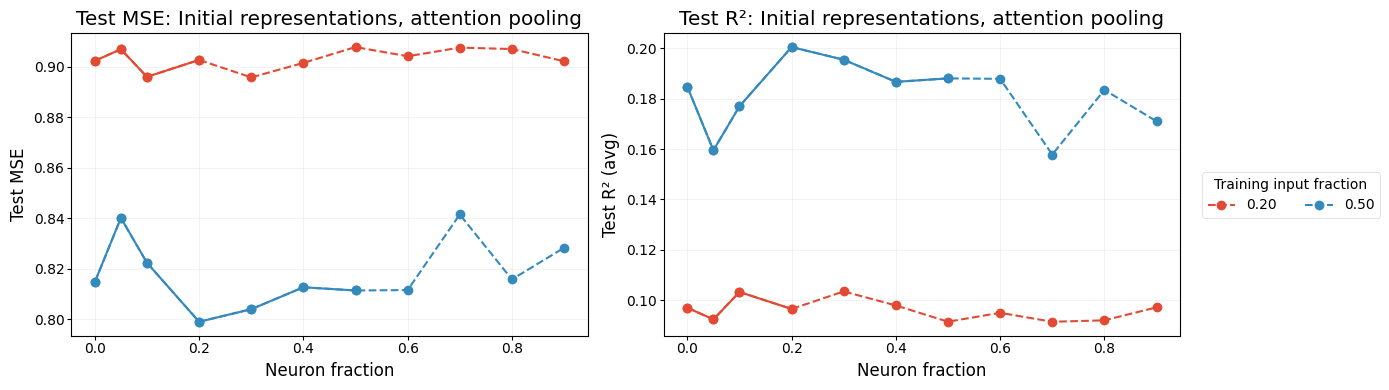

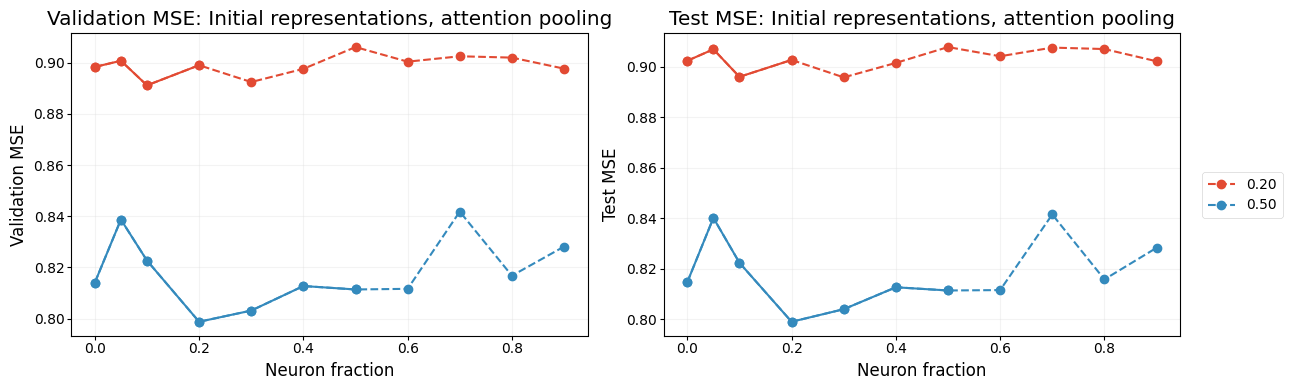

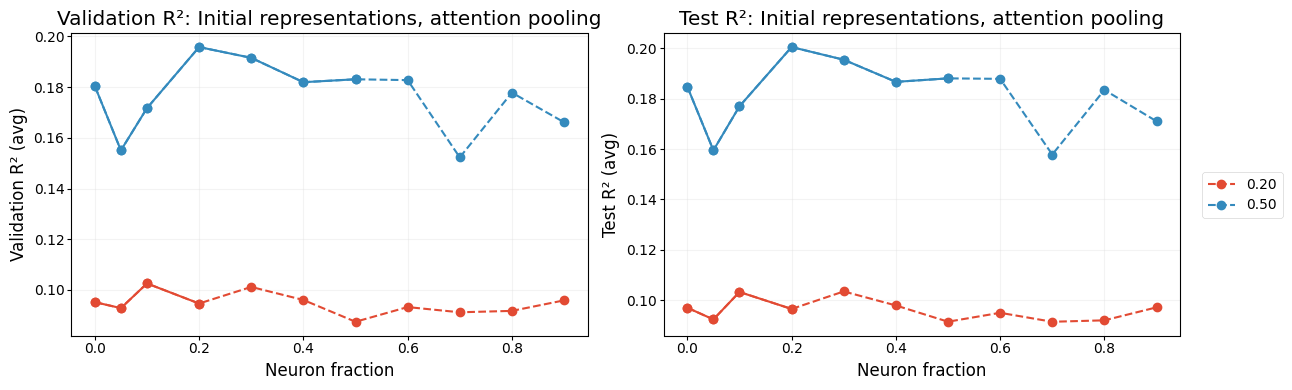

In [72]:
args.pooling_type = "attention_p"
args.representation_type = "initial"
K = 24
ALPHA = "max"
LR = "004"
output_dirs = [
    # f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_00_s_{SEED}",
    # f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_05_s_{SEED}",
    f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_20_s_{SEED}",
    f"/mnt/lustre-grete/usr/u12008/decoding/k_{K}_a_{ALPHA}_b1e7_poisson/k_{K}_a_{ALPHA}_xyz_nosubsel_1dLL_lrx{LR}_meanbias_2dpe_bef_core_bs_16_frac0_50_s_{SEED}",
]

plot_best_by_fraction(
    output_dirs=output_dirs,
    representation_type=args.representation_type,        # matches your analysis/<rep_type>
    pooling_type=args.pooling_type,
    csv_name=f"best_by_fraction_{args.pooling_type}.csv",      # or whatever you used
    labels=[ "0.20", "0.50"],        # optional
    save_prefix=None,   # or None to just show
    title= f"Initial representations, attention pooling",
    train_fracs=[ 0.20, 0.50],
)


## Plot across models responses probes

In [15]:
def plot_best_by_fraction_datasets(
    output_dirs: Sequence[str | Path],
    csv_name: str = "best_by_fraction.csv",
    labels: Sequence[str] | None = None,
    title: str | None = None,
    save_prefix: str | None = None,
):
    output_dirs = [Path(d) for d in output_dirs]

    if labels is None:
        labels = [d.name for d in output_dirs]
    assert len(labels) == len(output_dirs), "labels must match output_dirs length"

    # --- load ---
    dfs = []
    for d, label in zip(output_dirs, labels):
        csv_path = d / csv_name

        df = pd.read_csv(csv_path)
        if "frac" not in df.columns:
            print(f"[warn] no 'frac' column in {csv_path}, skipping.")
            continue

        # ensure numeric + sorted
        df["frac"] = pd.to_numeric(df["frac"], errors="coerce")
        df = df.dropna(subset=["frac"]).sort_values("frac").reset_index(drop=True)

        # make sure the fields exist if present as strings
        for col in ["final_val_mse", "final_test_mse", "final_val_corr", "final_test_corr"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")

        df["__label"] = label
        dfs.append(df)

    if not dfs:
        print("[error] no valid CSVs found.")
        return

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    # -------------------------
    # Figure : test MSE & R2
    # -------------------------
    fig_mse, (ax_test_r2, ax_test_mse) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for i, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[i % len(colors)]
        x = df["frac"].to_numpy()
        if "final_test_mse" in df.columns:
            ax_test_mse.plot(x, df["final_test_mse"].to_numpy(), marker="o", linestyle="-",
                             color=color, label=label)
        if "final_val_mse" in df.columns:
            ax_test_r2.plot(x, df["final_test_r2avg"].to_numpy(), marker="o", linestyle="-",
                            color=color, label=label)


    ax_test_r2.set_xlabel("Neuron fraction")
    ax_test_r2.set_ylabel("Test R2")
    ax_test_r2.set_title("Test R2" + (f": {title}" if title else ""))
    ax_test_r2.grid(alpha=0.3)

    ax_test_mse.set_xlabel("Neuron fraction")
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title("Test MSE" + (f": {title}" if title else ""))
    ax_test_mse.grid(alpha=0.3)

    handles, lab = ax_test_r2.get_legend_handles_labels()
    fig_mse.legend(handles, lab, bbox_to_anchor=(1.0, 0.5), loc="center left", title="Dataset")
    fig_mse.tight_layout()
    # -------------------------
    # Figure : test MSE & corr
    # -------------------------
    fig_mse, (ax_test_corr, ax_test_mse) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for i, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[i % len(colors)]
        x = df["frac"].to_numpy()

        if "final_val_mse" in df.columns:
            ax_test_corr.plot(x, df["final_test_corr"].to_numpy(), marker="o", linestyle="-",
                            color=color, label=label)
        if "final_test_mse" in df.columns:
            ax_test_mse.plot(x, df["final_test_mse"].to_numpy(), marker="o", linestyle="-",
                             color=color, label=label)

    ax_test_corr.set_xlabel("Neuron fraction")
    ax_test_corr.set_ylabel("Test Correlation")
    ax_test_corr.set_title("Test Correlation" + (f": {title}" if title else ""))
    ax_test_corr.grid(alpha=0.3)

    ax_test_mse.set_xlabel("Neuron fraction")
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title("Test MSE" + (f": {title}" if title else ""))
    ax_test_mse.grid(alpha=0.3)

    handles, lab = ax_test_corr.get_legend_handles_labels()
    fig_mse.legend(handles, lab, bbox_to_anchor=(1.0, 0.5), loc="center left", title="Dataset")
    fig_mse.tight_layout()
    # -------------------------
    # Figure 1: MSE
    # -------------------------
    fig_mse, (ax_val_mse, ax_test_mse) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for i, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[i % len(colors)]
        x = df["frac"].to_numpy()

        if "final_val_mse" in df.columns:
            ax_val_mse.plot(x, df["final_val_mse"].to_numpy(), marker="o", linestyle="-",
                            color=color, label=label)
        if "final_test_mse" in df.columns:
            ax_test_mse.plot(x, df["final_test_mse"].to_numpy(), marker="o", linestyle="-",
                             color=color, label=label)

    ax_val_mse.set_xlabel("Neuron fraction")
    ax_val_mse.set_ylabel("Validation MSE")
    ax_val_mse.set_title("Validation MSE" + (f": {title}" if title else ""))
    ax_val_mse.grid(alpha=0.3)

    ax_test_mse.set_xlabel("Neuron fraction")
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title("Test MSE" + (f": {title}" if title else ""))
    ax_test_mse.grid(alpha=0.3)

    handles, lab = ax_val_mse.get_legend_handles_labels()
    fig_mse.legend(handles, lab, bbox_to_anchor=(1.0, 0.5), loc="center left", title="Dataset")
    fig_mse.tight_layout()

    # -------------------------
    # Figure 2: Corr
    # -------------------------
    fig_corr, (ax_val_corr, ax_test_corr) = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

    for i, df in enumerate(dfs):
        label = df["__label"].iloc[0]
        color = colors[i % len(colors)]
        x = df["frac"].to_numpy()

        if "final_val_corr" in df.columns:
            ax_val_corr.plot(x, df["final_val_corr"].to_numpy(), marker="o", linestyle="-",
                             color=color, label=label)
        if "final_test_corr" in df.columns:
            ax_test_corr.plot(x, df["final_test_corr"].to_numpy(), marker="o", linestyle="-",
                              color=color, label=label)

    ax_val_corr.set_xlabel("Neuron fraction")
    ax_val_corr.set_ylabel("Correlation")
    ax_val_corr.set_title("Validation Correlation" + (f": {title}" if title else ""))
    ax_val_corr.grid(alpha=0.3)

    ax_test_corr.set_xlabel("Neuron fraction")
    ax_test_corr.set_ylabel("Correlation")
    ax_test_corr.set_title("Test Correlation" + (f": {title}" if title else ""))
    ax_test_corr.grid(alpha=0.3)

    handles, lab = ax_val_corr.get_legend_handles_labels()
    fig_corr.legend(handles, lab, bbox_to_anchor=(1.0, 0.5), loc="center left", title="Dataset")
    fig_corr.tight_layout()

    if save_prefix is None:
        plt.show()
    else:
        # save next to first output dir by default
        save_dir = output_dirs[0]
        fig_mse.savefig(save_dir / f"{save_prefix}_mse.png", dpi=150, bbox_inches="tight")
        fig_corr.savefig(save_dir / f"{save_prefix}_corr.png", dpi=150, bbox_inches="tight")
        plt.close(fig_mse)
        plt.close(fig_corr)

In [16]:
def parse_alpha(s: str) -> float:
    s = s.strip()

    # e.g. "1_1" -> 1.1, "10_05" -> 10.05
    if "_" in s:
        a, b = s.split("_", 1)
        a = a or "0"
        b = b or "0"
        return float(f"{int(a)}.{b}")

    # e.g. "00" -> 0.0, "09" -> 0.9, "12" -> 1.2, "105" -> 10.5
    if s.isdigit() and len(s) >= 2:
        int_part = int(s[:-1])   # keeps leading zeros from mattering
        frac_part = s[-1]
        return float(f"{int_part}.{frac_part}")

    # e.g. "0" -> 0.0, "5" -> 5.0
    return float(int(s))

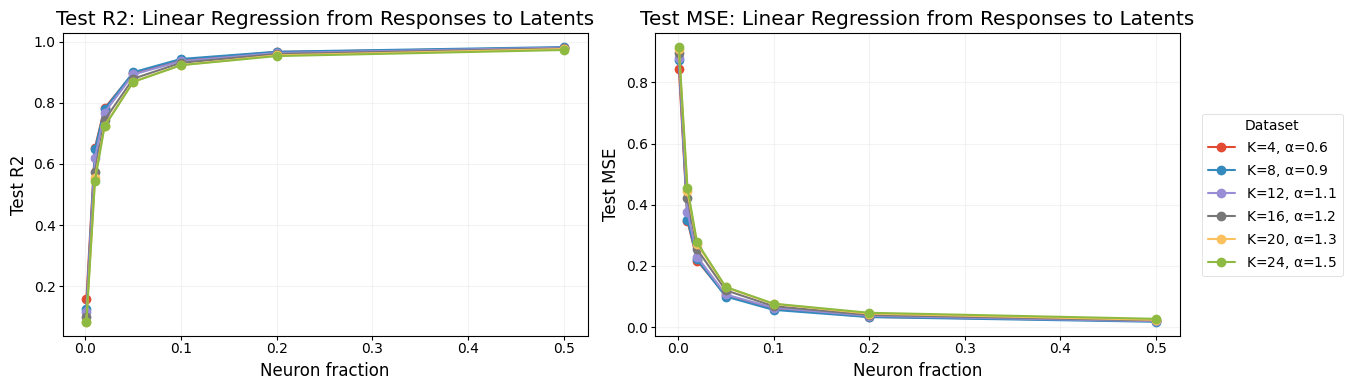

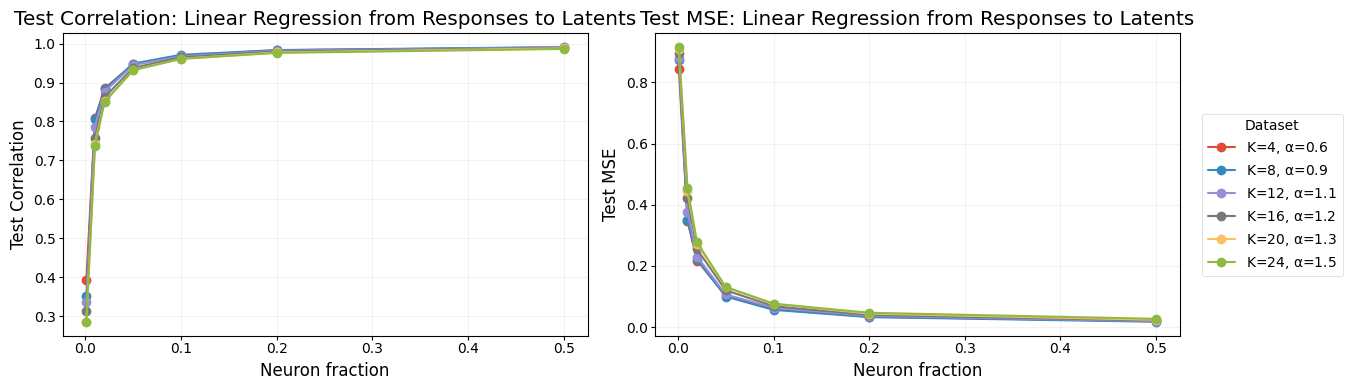

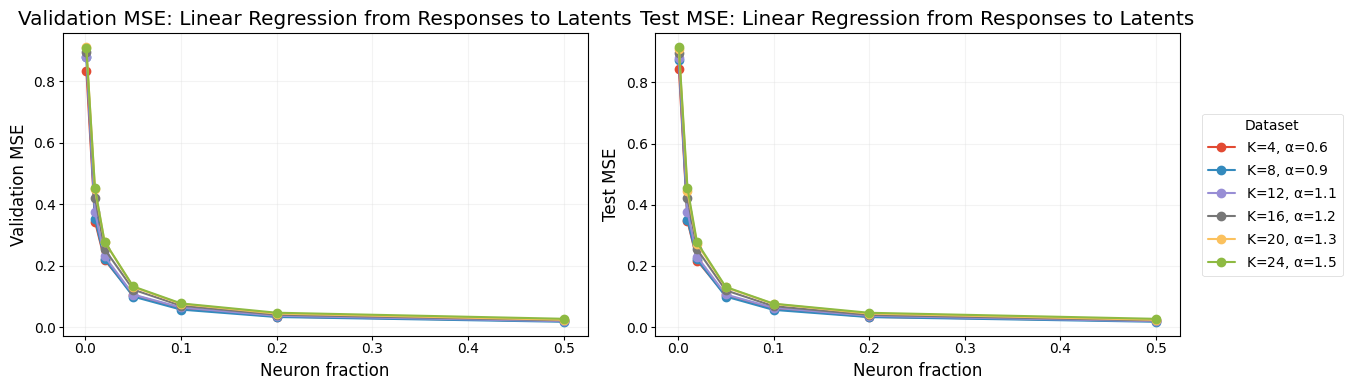

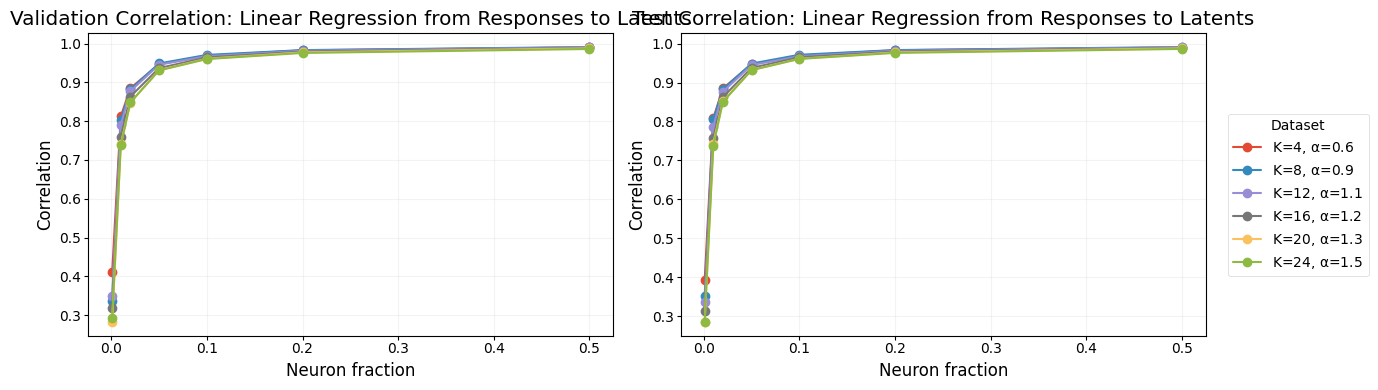

In [18]:
Ks = [4, 8, 12, 16, 20, 24]
ALPHAs = ["06", "09", "1_1", "1_2", "1_3", "1_5"]
# ALPHAs = ["max", "max","max","max","max","max"]

output_dirs = [
    f"/mnt/lustre-grete/usr/u12008/responses_{lat}probe/k_{K}_a_{A}_b1e7_poisson"
    for K, A in zip(Ks, ALPHAs)
]
# ALPHAs = [np.load(f"/user/azhar.akhmetova/u12008/neuro-transformer/misc/analysis/latents/k_{k}/alpha_k_{k}.npy") for k in Ks]
labels = [
    rf"K={K}, $\alpha$={parse_alpha(A)}" #A:.2f
    for K, A in zip(Ks, ALPHAs)
]

plot_best_by_fraction_datasets(
    output_dirs=output_dirs,
    csv_name="best_by_fraction_corr.csv",
    labels=labels,
    title="Linear Regression from Responses to Latents",
    save_prefix=None,
)

In [13]:
import pandas as pd
p = "/mnt/lustre-grete/usr/u12008/responses_probe/k_16_a_1_2_b1e7_poisson/best_by_fraction_corr.csv"
df = pd.read_csv(p)
df.head(7)

,frac,sweep_id,run_id,final_val_mse,final_test_mse,final_val_r2avg,final_test_r2avg,final_val_corr,final_test_corr
0,0.001,o6z4fhcp,lgmqo2qr,4.973050,4.936946,0.025805,0.024459,0.161647,0.158330
1,0.010,8e7kungw,3k1088yv,4.593012,4.556676,0.072967,0.072376,0.338845,0.334578
2,0.020,eg35sve3,89ohlgx5,8.821108,8.794194,-0.082377,-0.083489,0.387799,0.384894
3,0.050,wd2xp7df,me0zb1k0,4.081156,4.067675,0.249873,0.245372,0.497791,0.493402
4,0.200,33kp7pnf,a6mkdwff,9.630323,9.629598,-0.023429,-0.029732,0.526822,0.522549
5,0.500,4r8yt626,er21jj74,4.670538,4.663332,0.244172,0.239983,0.517925,0.514177


## with global r2

In [ ]:
from pathlib import Path
from typing import Sequence
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_sst_per_tier(latents_path: str | Path,
                         tiers_path: str | Path) -> dict[str, np.ndarray]:
    """
    Compute SST_k for each tier (train/validation/test) and each latent dim k.

    Returns
    -------
    sst : dict
        Keys: "train", "validation", "test".
        Values: np.ndarray of shape [K] with SST per latent dim.
    """
    latents_path = Path(latents_path)
    tiers_path = Path(tiers_path)

    z = np.load(latents_path, mmap_mode="r")  # [T_all, K]
    tiers = np.load(tiers_path)               # [T_all], e.g. "train"/"validation"/"test"

    sst = {}
    for tier in ["train", "validation", "test"]:
        idx = np.nonzero(tiers == tier)[0]
        if idx.size == 0:
            continue
        z_tier = z[idx]                       # [T_tier, K]
        mean = z_tier.mean(axis=0, keepdims=True)
        diff = z_tier - mean
        sst[tier] = (diff ** 2).sum(axis=0)   # [K]
    return sst


def _parse_list_column(x):
    """Parse list-like column from CSV (JSON or repr)."""
    if isinstance(x, list):
        return x
    if x is None:
        return []
    s = str(x).strip()
    if not s:
        return []
    # Try JSON first
    try:
        v = json.loads(s)
        if isinstance(v, list):
            return v
    except Exception:
        pass
    # Fallback: "[0.1, 0.2, 0.3]" or "0.1, 0.2, 0.3"
    s = s.strip("[]")
    if not s:
        return []
    return [float(t) for t in s.split(",")]


def _add_global_r2_columns(df: pd.DataFrame,
                           sst_val: np.ndarray,
                           sst_test: np.ndarray) -> pd.DataFrame:
    """
    Given a best_by_fraction dataframe with final_*_r2_each columns
    and SST per latent dim for val/test, add global R² columns.
    """
    def global_r2_from_row(row, col_each, sst_vec):
        r2_list = _parse_list_column(row.get(col_each))
        if not r2_list or sst_vec is None:
            return np.nan
        r2 = np.asarray(r2_list, dtype=float)
        sst_vec = np.asarray(sst_vec, dtype=float)
        if r2.shape != sst_vec.shape:
            return np.nan
        return float((sst_vec * r2).sum() / sst_vec.sum())

    df = df.copy()
    df["global_val_r2"] = df.apply(
        lambda row: global_r2_from_row(row, "final_val_r2_each", sst_val),
        axis=1,
    )
    df["global_test_r2"] = df.apply(
        lambda row: global_r2_from_row(row, "final_test_r2_each", sst_test),
        axis=1,
    )
    return df


def plot_best_by_fraction_with_global_r2(
    output_dirs: Sequence[str | Path],
    latents_path: str | Path,
    tiers_path: str | Path = "/user/azhar.akhmetova/merged_sensorium/meta/trials/tiers.npy",
    representation_type: str = "initial",
    csv_name: str = f"best_by_fraction.csv",
    labels: Sequence[str] | None = None,
    save_prefix: str | None = None,
    title: str = "",
):
    """
    For each output_dir, load analysis/<representation_type>/<csv_name>,
    attach global R² computed from r2_each and latents, and plot:

      - val/test MSE vs fraction (2 subplots)
      - val/test R²_avg vs fraction, plus global R² curves (2 subplots).
    """
    output_dirs = [Path(d) for d in output_dirs]

    if labels is None:
        labels = [d.name for d in output_dirs]
    assert len(labels) == len(output_dirs), "labels must match output_dirs length"

    # --- SST from latents ---
    sst = compute_sst_per_tier(latents_path, tiers_path)
    sst_val = sst.get("validation")
    sst_test = sst.get("test")

    # --- Load and augment CSVs ---
    dfs = []
    for d, label in zip(output_dirs, labels):
        csv_path = d / "analysis" / representation_type / csv_name
        if not csv_path.is_file():
            print(f"[warn] missing CSV for {label}: {csv_path}")
            continue
        df = pd.read_csv(csv_path)
        if "frac" not in df.columns:
            print(f"[warn] no 'frac' column in {csv_path}, skipping.")
            continue
        df["__label"] = label
        df = df.sort_values("frac").reset_index(drop=True)
        df = _add_global_r2_columns(df, sst_val=sst_val, sst_test=sst_test)
        dfs.append(df)

    if not dfs:
        print("[error] no valid best_by_fraction.csv files found.")
        return

    base_save_dir = (
        output_dirs[0] / "analysis" / representation_type
        if save_prefix is not None
        else None
    )
    if base_save_dir is not None:
        base_save_dir.mkdir(parents=True, exist_ok=True)

    # -------------------------
    # 1) MSE vs fraction plots
    # -------------------------
    fig_mse, (ax_val_mse, ax_test_mse) = plt.subplots(
        1, 2, figsize=(10, 4), sharex=True
    )

    for df in dfs:
        label = df["__label"].iloc[0]
        fracs = df["frac"].values
        if "final_val_mse" in df.columns:
            ax_val_mse.plot(fracs, df["final_val_mse"].values, marker="o", label=label)
        if "final_test_mse" in df.columns:
            ax_test_mse.plot(fracs, df["final_test_mse"].values, marker="o", label=label)

    ax_val_mse.set_xlabel("Neuron fraction")
    ax_val_mse.set_ylabel("Validation MSE")
    ax_val_mse.set_title("Validation MSE:" + title)
    ax_val_mse.grid(alpha=0.3)
    ax_val_mse.legend()

    ax_test_mse.set_xlabel("Neuron fraction")
    ax_test_mse.set_ylabel("Test MSE")
    ax_test_mse.set_title("Test MSE:" + title)
    ax_test_mse.grid(alpha=0.3)
    ax_test_mse.legend()

    fig_mse.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        mse_path = base_save_dir / f"{save_prefix}_mse.png"
        fig_mse.savefig(mse_path, dpi=150)
        print(f"[ok] saved MSE figure -> {mse_path}")

    # -------------------------
    # 2) R² vs fraction plots
    # -------------------------
    fig_r2, (ax_val_r2, ax_test_r2) = plt.subplots(
        1, 2, figsize=(10, 4), sharex=True
    )

    for df in dfs:
        label = df["__label"].iloc[0]
        fracs = df["frac"].values

        # average per-dim R²
        if "final_val_r2avg" in df.columns:
            ax_val_r2.plot(
                fracs, df["final_val_r2avg"].values,
                marker="o", linestyle="-", label=f"{label} (avg)"
            )
        if "final_test_r2avg" in df.columns:
            ax_test_r2.plot(
                fracs, df["final_test_r2avg"].values,
                marker="o", linestyle="-", label=f"{label} (avg)"
            )

        # global variance-weighted R²
        if "global_val_r2" in df.columns:
            ax_val_r2.plot(
                fracs, df["global_val_r2"].values,
                marker="s", linestyle="--", label=f"{label} (global)"
            )
        if "global_test_r2" in df.columns:
            ax_test_r2.plot(
                fracs, df["global_test_r2"].values,
                marker="s", linestyle="--", label=f"{label} (global)"
            )

    ax_val_r2.set_xlabel("Neuron fraction")
    ax_val_r2.set_ylabel("Validation R²")
    ax_val_r2.set_title("Validation R²:" + title)
    ax_val_r2.grid(alpha=0.3)
    ax_val_r2.legend()

    ax_test_r2.set_xlabel("Neuron fraction")
    ax_test_r2.set_ylabel("Test R²")
    ax_test_r2.set_title("Test R²:" + title)
    ax_test_r2.grid(alpha=0.3)
    ax_test_r2.legend()

    fig_r2.tight_layout()
    if save_prefix is not None and base_save_dir is not None:
        r2_path = base_save_dir / f"{save_prefix}_r2.png"
        fig_r2.savefig(r2_path, dpi=150)
        print(f"[ok] saved R² figure -> {r2_path}")

    if save_prefix is None:
        plt.show()
    else:
        plt.close(fig_mse)
        plt.close(fig_r2)


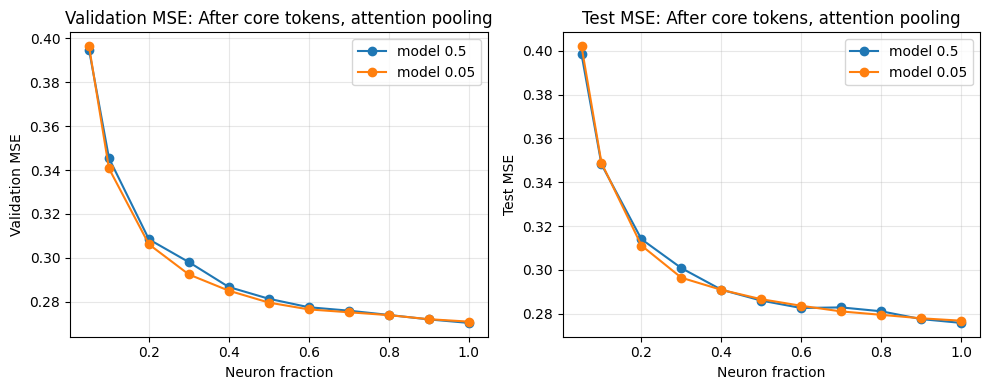

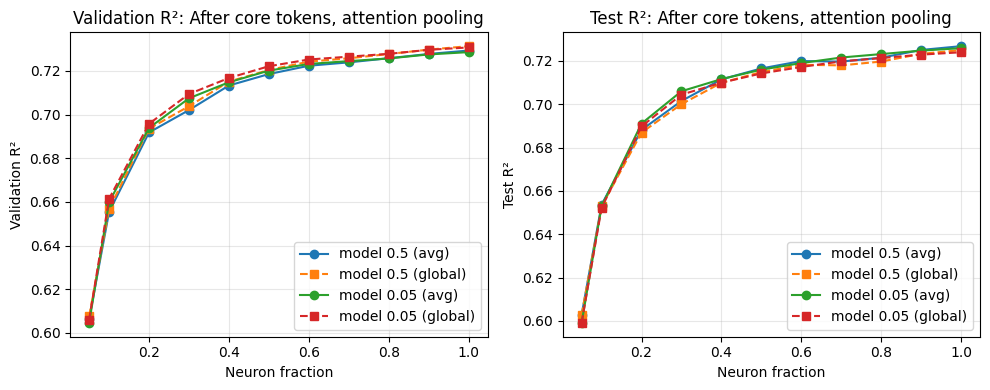

In [ ]:
output_dirs = [
    "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_5_2dpe_bef_core",
    "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core",
]
# representation_type = "after core"
plot_best_by_fraction_with_global_r2(
    output_dirs=output_dirs,
    latents_path="/user/azhar.akhmetova/sensorium_clusters/syn_data_generation/beta10e7/23343-5-17/xyz/k_4/z_k_4_no_train_dupl.npy",
    tiers_path="/user/azhar.akhmetova/merged_sensorium/meta/trials/tiers.npy",
    representation_type="after_core",            # or "after_sa", etc.
    csv_name=f"best_by_fraction_{args.pooling_type}.csv",
    labels=["model 0.5", "model 0.05"],
    save_prefix=None,
    title= f" After core tokens, attention pooling"
)


## Draft

In [ ]:
def load_results_from_csv(csv_path):
    """Load CSV and convert to results format (list of dicts)"""
    df = pd.read_csv(csv_path)
    
    # Convert DataFrame to list of dicts (same format as results)
    results = []
    for _, row in df.iterrows():
        result_dict = {
            "frac": float(row["frac"]),
            "final_val_mse": float(row["final_val_mse"]),
            "final_test_mse": float(row["final_test_mse"]),
            "final_val_r2avg": float(row["final_val_r2avg"]),
            "final_test_r2avg": float(row["final_test_r2avg"]),
            # Add other columns as needed
        }
        results.append(result_dict)
    
    return results

# Load your CSV
csv_path = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_old/best_per_fraction.csv"


In [22]:
def parse_fractions(frac_arg: str | None):
    if frac_arg:
        return [float(x) for x in frac_arg.split(",")]
    # default ladder: 0.05, 0.1, 0.2, ..., 1.0
    return [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

def best_row(df: pd.DataFrame) -> pd.Series:
    if "final_val_mse" in df.columns and df["final_val_mse"].notna().any():
        return df.loc[df["final_val_mse"].astype(float).idxmin()]
    # fallback to early-stopping metric if needed
    return df.loc[df["best_val_loss"].astype(float).idxmin()]

def parse_frac_from_dir(sel_dir: Path):
    # sel_dir.name like "sel_frac_0.05" or "sel_frac_1.0"
    try:
        return float(sel_dir.name.split("sel_frac_")[1])
    except Exception:
        return None

def best_row_from_csv(csv_path: Path):
    best = None
    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                v = float(row["final_val_mse"])
            except Exception:
                continue
            if (best is None) or (v < float(best["final_val_mse"])):
                best = row
    return best

In [27]:
output_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"

In [28]:
ap = argparse.ArgumentParser()
ap.add_argument("--output_dir", required=True, help="Root run dir used by decoding script")
ap.add_argument("--fractions", default=None, help="Comma-separated list, e.g. '0.05,0.1,0.2,...,1'")
ap.add_argument("--out_csv", default="best_per_fraction.csv")
ap.add_argument("--out_dir", default=None, help="Where to save CSV/plots (defaults to analysis/initial_tokens)")
args = ap.parse_args([
    "--output_dir", f"{output_dir}",
])

fracs = parse_fractions(args.fractions)

In [ ]:
def collect_best_by_fraction(base_dir: str):
    base = Path(base_dir) / "analysis" / "initial_tokens"
    results = {}  # frac -> best_row
    # Discover all fraction folders irrespective of formatting
    for sel_dir in base.glob("sel_frac_*"):
        frac = parse_frac_from_dir(sel_dir)
        if frac is None:
            continue
        # find all metrics.csv under any sweep folder, robustly
        csv_paths = list(sel_dir.rglob("metrics.csv"))
        best = None
        for csv_path in csv_paths:
            row = best_row_from_csv(csv_path)
            if row is None:
                continue
            if (best is None) or (float(row["final_val_mse"]) < float(best["final_val_mse"])):
                best = row
        if best is not None:
            results[frac] = best
    return results

def to_float_list(x):
    # rows may store lists as JSON strings or Python-list repr; handle both
    if x is None or x == "" or x == "None":
        return None
    if isinstance(x, list):
        return [float(v) for v in x]
    s = str(x).strip()
    try:
        # try JSON first
        v = json.loads(s)
        return [float(u) for u in v]
    except Exception:
        pass
    # try Python literal style: "[0.1, 0.2, 0.3]"
    s = s.strip("[]")
    if not s:
        return []
    return [float(t) for t in s.split(",")]


In [19]:
base_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"
best_by_frac = collect_best_by_fraction(base_dir)

In [ ]:
def plot_mse(results, out_png="mse_vs_frac.png"):
    fracs = sorted(results.keys())
    val = [float(results[f]["final_val_mse"]) for f in fracs]
    test = [float(results[f]["final_test_mse"]) for f in fracs]

    # Val
    plt.figure()
    plt.plot(fracs, val, marker="o")
    plt.xlabel("Fraction of neurons")
    plt.ylabel("Validation MSE")
    plt.title("Validation MSE vs fraction")
    plt.grid(True, alpha=0.3)
    plt.savefig(out_png.replace(".png", "_val.png"), bbox_inches="tight")

    # Test
    plt.figure()
    plt.plot(fracs, test, marker="o")
    plt.xlabel("Fraction of neurons")
    plt.ylabel("Test MSE")
    plt.title("Test MSE vs fraction")
    plt.grid(True, alpha=0.3)
    plt.savefig(out_png.replace(".png", "_test.png"), bbox_inches="tight")

# ===== Run =====
# base_dir is the same --output_dir you passed to training
base_dir = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core"
best_by_frac = collect_best_by_fraction(base_dir)

# optional: inspect one fraction’s extra metrics
# e.g. pearson_each/r2_each may be serialized as JSON or Python repr in CSV
for frac in sorted(best_by_frac.keys()):
    row = best_by_frac[frac]
    pearson_each = to_float_list(row.get("final_val_psnr"))
    r2_each = to_float_list(row.get("final_val_r2_each"))
    # print or store if needed
    # print(frac, row["final_val_mse"], pearson_each, r2_each)

plot_mse(best_by_frac)
print("Fractions found:", sorted(best_by_frac.keys()))

In [29]:
base_ai = os.path.join(args.output_dir, "analysis", "initial_tokens")
save_dir = args.out_dir or base_ai
os.makedirs(save_dir, exist_ok=True)

rows = []
for f in fracs:
    # frac_str = f"{f:g}"  # matches your 'sel_frac_{frac}' naming
    frac_str = f"{f:.2f}".rstrip("0").rstrip(".")  # 0.50 -> 0.5, 1.00 -> 1

    sel_dir = os.path.join(base_ai, f"sel_frac_{frac_str}")
    frac = parse_frac_from_dir(sel_dir)

    # Find all metrics.csv inside sweep-* under this fraction
    csv_paths = glob.glob(os.path.join(sel_dir, "sweep-*", "metrics.csv"))
    if not csv_paths:
        print(f"[warn] no metrics.csv for fraction {frac_str} under {sel_dir}")
        continue

    # Concatenate all sweep metrics for this fraction
    dfs = []
    for p in csv_paths:
        try:
            dfp = pd.read_csv(p)
            dfp["__metrics_csv_path"] = p
            dfs.append(dfp)
        except Exception as e:
            print(f"[warn] skipping unreadable {p}: {e}")
    if not dfs:
        print(f"[warn] all metrics unreadable for fraction {frac_str}")
        continue

    all_runs = pd.concat(dfs, ignore_index=True)

    # Pick best row by final_val_mse (fallback: best_val_loss)
    try:
        br = best_row(all_runs)
    except Exception as e:
        print(f"[warn] cannot pick best for frac {frac_str}: {e}")
        continue

    # Extract required metrics (handle lists stored as JSON-like strings)
    def as_list(x):
        if isinstance(x, list):
            return x
        if isinstance(x, str):
            try:
                v = json.loads(x)
                return v if isinstance(v, list) else None
            except Exception:
                return None
        return None

    rows.append({
        "frac": float(frac_str),
        "sweep_id": br.get("sweep_id"),
        "run_id": br.get("run_id"),
        "run_name": br.get("run_name"),
        "ds_pool": br.get("ds_pool"),
        "reg": br.get("reg"),
        "lr": br.get("lr"),
        "wd": br.get("wd"),
        "l1": br.get("l1"),
        "final_val_mse": float(br.get("final_val_mse", np.nan)),
        "final_test_mse": float(br.get("final_test_mse", np.nan)),
        "final_val_r2avg": float(br.get("final_val_r2avg", np.nan)),
        "final_test_r2avg": float(br.get("final_test_r2avg", np.nan)),
        "final_val_r2_each": as_list(br.get("final_val_r2_each")),
        "final_test_r2_each": as_list(br.get("final_test_r2_each")),
        "final_val_psnr": as_list(br.get("final_val_psnr")),   # pearson_each
        "final_test_psnr": as_list(br.get("final_test_psnr")),
        "__metrics_csv_path": br.get("__metrics_csv_path"),
    })

if not rows:
    print("[error] no data collected; nothing to save/plot.")

best_df = pd.DataFrame(rows).sort_values("frac").reset_index(drop=True)
save_best = True
if save_best:
    out_csv_path = os.path.join(save_dir, args.out_csv)
    best_df.to_csv(out_csv_path, index=False)
    print(f"[ok] saved best-per-fraction table -> {out_csv_path}")

[warn] no metrics.csv for fraction 1 under /user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_tokens/sel_frac_1
[ok] saved best-per-fraction table -> /user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_tokens/best_per_fraction.csv


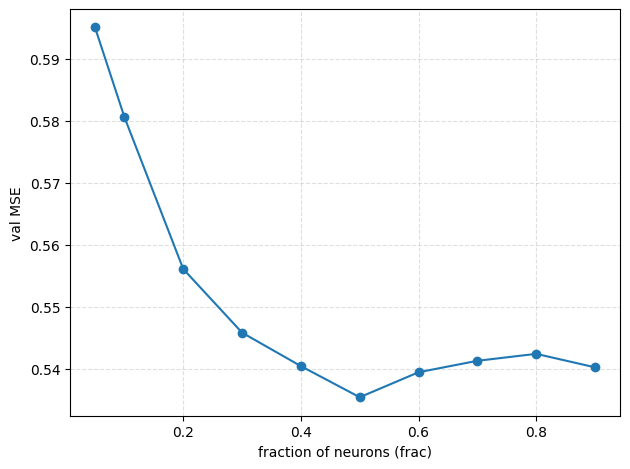

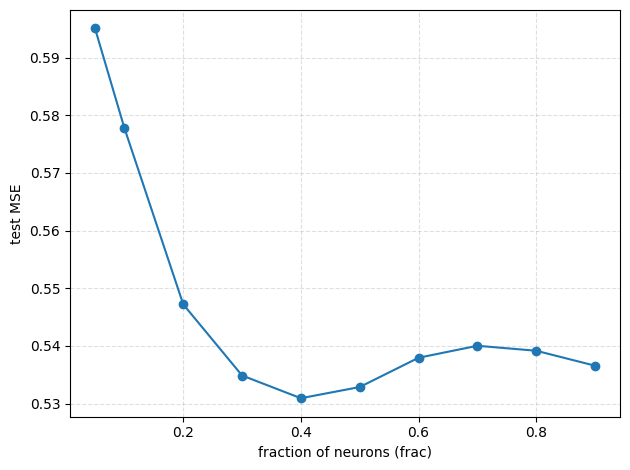

In [26]:
# Plots
def plot_xy(x, y, ylabel, fname, save_fig=False):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel("fraction of neurons (frac)")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_fig:
        outp = os.path.join(save_dir, fname)
        plt.savefig(outp, dpi=160)
        print(f"[ok] saved plot -> {outp}")
    plt.show()
    plt.close()

plot_xy(best_df["frac"], best_df["final_val_mse"], "val MSE", "val_mse_vs_frac.png")
plot_xy(best_df["frac"], best_df["final_test_mse"], "test MSE", "test_mse_vs_frac.png")

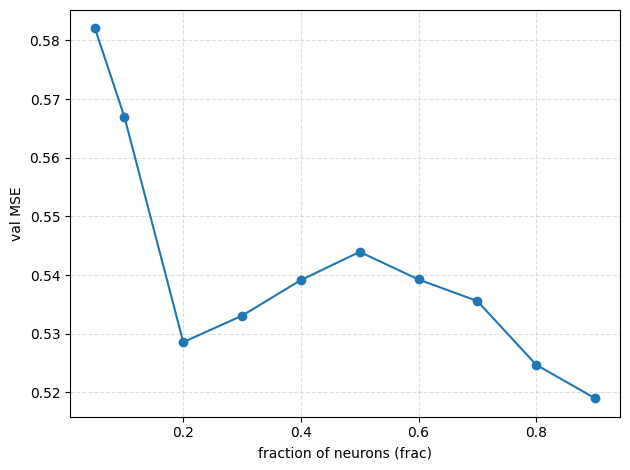

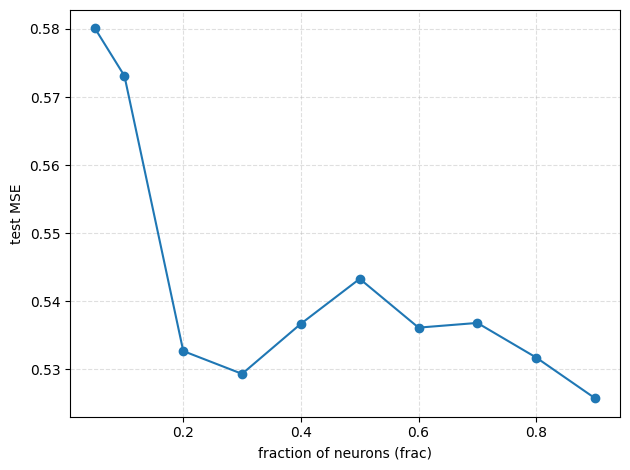

In [30]:
# Plots
def plot_xy(x, y, ylabel, fname, save_fig=False):
    plt.figure()
    plt.plot(x, y, marker="o")
    plt.xlabel("fraction of neurons (frac)")
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    if save_fig:
        outp = os.path.join(save_dir, fname)
        plt.savefig(outp, dpi=160)
        print(f"[ok] saved plot -> {outp}")
    plt.show()
    plt.close()

plot_xy(best_df["frac"], best_df["final_val_mse"], "val MSE", "val_mse_vs_frac.png")
plot_xy(best_df["frac"], best_df["final_test_mse"], "test MSE", "test_mse_vs_frac.png")

In [ ]:
def load_results_from_csv(csv_path):
    """Load CSV and convert to results format (list of dicts)"""
    df = pd.read_csv(csv_path)
    
    # Convert DataFrame to list of dicts (same format as results)
    results = []
    for _, row in df.iterrows():
        result_dict = {
            "frac": float(row["frac"]),
            "final_val_mse": float(row["final_val_mse"]),
            "final_test_mse": float(row["final_test_mse"]),
            "final_val_r2avg": float(row["final_val_r2avg"]),
            "final_test_r2avg": float(row["final_test_r2avg"]),
            # Add other columns as needed
        }
        results.append(result_dict)
    
    return results

# Load your CSV
csv_path = "/user/azhar.akhmetova/corrViT/runs_debug/analysis/k_4_xyz_no_subselect_fixed/k_4_a_03_xyz_nosubsel_1dLL_lrx04_meanbias_s_1_frac0_05_2dpe_bef_core/analysis/initial_old/best_per_fraction.csv"
